<a href="https://colab.research.google.com/github/WVF-1/Utopia-25-Cellular-Automata-Experiment/blob/main/Utopia_25_Macro_Layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐀 Utopia 25 — Hierarchical Two-Layer Cellular Automata

> *"The pathological togetherness" — John B. Calhoun*

This notebook extends the micro-layer agent simulation into a **hierarchical two-scale system**:

| Layer | Description |
|---|---|
| **Micro** | 5×5 hex-grid rat-agent colonies (one per macro cell) |
| **Macro** | 16×16 environmental CA grid — cells interact via statistical diffusion |

### Architecture
| Phase | Content |
|---|---|
| 1–8 | Micro-layer foundation (preserved from micro notebook) |
| 9 | Macro constants, palette |
| 10 | `MacroCellStats` dataclass + `MacroCell` class |
| 11 | `MacroGrid` class — Moore neighborhoods, toroidal wrapping, diffusion |
| 12 | Macro visualisations (heatmap, phase map, global curves, inspection panel) |
| 13 | Run macro experiment |
| 14 | Analysis |

### Collapse Mechanism
Collapse is driven **entirely** by withdrawal, social fragmentation, and reproductive failure — no disease, predation, or starvation. Macro cells influence neighbours through **statistical diffusion** of withdrawal ratio, stress, and behavioural energy.

### Behavioural Energy (Gibbs-inspired)
$$E = w_1 \cdot \phi_W + w_2 \cdot \rho + w_3 \cdot \sigma^2_S - w_4 \cdot r$$
where $\phi_W$ = withdrawal ratio, $\rho$ = occupancy pressure, $\sigma^2_S$ = stress variance, $r$ = reproduction rate.

---

## Phase 1 — Setup & Imports

In [81]:
import math, random, copy, itertools
from dataclasses import dataclass, field
from enum import Enum, auto
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.collections import PatchCollection
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

random.seed(42)
np.random.seed(42)

print(f"NumPy  {np.__version__}")
print(f"Pandas {pd.__version__}")
print(f"Matplotlib {matplotlib.__version__}")
print("\n✅ Imports OK.")


NumPy  2.0.2
Pandas 2.2.2
Matplotlib 3.10.0

✅ Imports OK.


In [82]:
# ── Colour palette ───────────────────────────────────────────────────────────
PALETTE = {
    "bg":          "#0d0d0d",
    "grid_empty":  "#1a1a2e",
    "grid_line":   "#2a2a4a",
    "active":      "#e8c547",
    "withdrawn":   "#4a90d9",
    "dead":        "#3a3a3a",
    "stress_lo":   "#1a472a",
    "stress_hi":   "#c0392b",
    "accent":      "#e74c3c",
    "text":        "#f0ebe3",
    "muted":       "#888888",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"],
    "axes.facecolor":   PALETTE["bg"],
    "axes.edgecolor":   PALETTE["muted"],
    "axes.labelcolor":  PALETTE["text"],
    "xtick.color":      PALETTE["muted"],
    "ytick.color":      PALETTE["muted"],
    "text.color":       PALETTE["text"],
    "grid.color":       PALETTE["grid_line"],
    "grid.alpha":       0.4,
    "legend.facecolor": "#1a1a2e",
    "legend.edgecolor": PALETTE["muted"],
    "font.family":      "monospace",
})

# ── Micro-layer global constants ─────────────────────────────────────────────
GRID_ROWS    = 10          # default micro grid (used by standalone Simulation)
GRID_COLS    = 10
MAX_TICKS    = 3000
MAX_AGENTS   = 12

ALPHA = 0.15;  BETA = 0.30;  GAMMA = 0.45;  DELTA = 0.10

WITHDRAW_THRESH             = 0.60
DEATH_STRESS_THRESH         = 0.90
STRESS_INTERACTION_INC      = 0.03
STRESS_ISOLATION_DEC        = 0.015
STRESS_DECAY                = 0.01
INTERACTION_THRESHOLD       = 3
BASE_REPRO_PROB             = 0.20
REPRO_MIN_AGE               = 10
REPRO_MAX_AGE               = 200
REPRO_STRESS_PENALTY        = 0.45
MAX_AGE                     = 300
SENESCENCE_START            = 220

WITHDRAWN_NEIGHBOR_INFLUENCE = 0.03
REPRO_FAILURE_DECAY          = 0.10
INHERITED_STRESS_FACTOR      = 0.35
SOCIAL_RESILIENCE_DECAY      = 0.97
JUVENILE_AGE_MAX             = 15
JUVENILE_STRESS_DEATH_PROB   = 0.03
SATURATION_THRESHOLD         = 500
INDIVIDUAL_RESILIENCE_RANGE  = (0.8, 1.2)
WITHDRAWAL_PERSISTENCE_TICKS = 6
CHRONIC_STRESS_FLOOR_WITHDRAWN = 0.25
RECOVERY_PROBABILITY         = 0.002

REPRO_MODIFIER_WITHDRAWN_DURATIONS = {
    (0, 25):        0.8,
    (26, 75):       0.5,
    (76, 150):      0.2,
    (151, math.inf):0.0,
}

print("✅ Constants defined.")


✅ Constants defined.


---
## Phase 2 — Hex Grid Engine

In [83]:
EVEN_ROW_DELTAS = [( 0,+1),( 0,-1),(-1,-1),(-1, 0),(+1,-1),(+1, 0)]
ODD_ROW_DELTAS  = [( 0,+1),( 0,-1),(-1, 0),(-1,+1),(+1, 0),(+1,+1)]

class HexGrid:
    """Odd-r offset hex grid with occupant tracking."""

    def __init__(self, rows: int, cols: int):
        self.rows = rows
        self.cols = cols
        self._occupants: Dict[Tuple[int,int], List[int]] = {
            (r,c): [] for r in range(rows) for c in range(cols)
        }
        self._neighbour_cache: Dict[Tuple[int,int], List[Tuple[int,int]]] = {}

    def neighbours(self, r, c):
        key = (r, c)
        if key not in self._neighbour_cache:
            deltas = ODD_ROW_DELTAS if r % 2 else EVEN_ROW_DELTAS
            self._neighbour_cache[key] = [
                (r+dr, c+dc) for dr,dc in deltas
                if 0 <= r+dr < self.rows and 0 <= c+dc < self.cols
            ]
        return self._neighbour_cache[key]

    def place(self, aid, r, c):
        self._occupants[(r,c)].append(aid)

    def remove(self, aid, r, c):
        if aid in self._occupants[(r,c)]:
            self._occupants[(r,c)].remove(aid)

    def move(self, aid, from_cell, to_cell):
        self.remove(aid, *from_cell)
        self.place(aid, *to_cell)

    def occupants(self, r, c):
        return list(self._occupants[(r,c)])

    def cell_count(self, r, c):
        return len(self._occupants[(r,c)])

    def total_agents(self):
        return sum(len(v) for v in self._occupants.values())

    def local_density(self, r, c):
        nbrs = self.neighbours(r, c)
        occ  = sum(1 for (nr,nc) in nbrs if self._occupants[(nr,nc)])
        occ += 1 if self._occupants[(r,c)] else 0
        return occ / (len(nbrs) + 1)

    def least_dense_neighbour(self, r, c):
        nbrs = self.neighbours(r, c)
        return min(nbrs, key=lambda cell: self.cell_count(*cell)) if nbrs else None

    @staticmethod
    def hex_to_pixel(r, c, size=1.0):
        return (size * math.sqrt(3) * (c + 0.5*(r%2)),
                size * 1.5 * r)

    def density_matrix(self):
        mat = np.zeros((self.rows, self.cols))
        for r in range(self.rows):
            for c in range(self.cols):
                mat[r,c] = self.cell_count(r,c)
        return mat

print("✅ HexGrid defined.")


✅ HexGrid defined.


---
## Phase 3 — Rat Agent

In [84]:
class AgentState(Enum):
    ACTIVE    = auto()
    WITHDRAWN = auto()
    DEAD      = auto()

@dataclass
class RatAgent:
    agent_id:                  int
    sex:                       str
    row:                       int
    col:                       int
    state:                     AgentState = field(default_factory=lambda: AgentState.ACTIVE)
    age:                       int   = 0
    stress:                    float = 0.0
    interactions:              int   = 0
    total_interactions:        int   = 0
    reproductive_success:      int   = 0
    withdrawal_pressure:       float = 0.0
    born_tick:                 int   = 0
    parent_ids:                Optional[Tuple[int,int]] = None
    inherited_stress:          float = 0.0
    social_resilience:         float = 1.0
    reproductive_confidence:   float = 1.0
    reproductive_failure_count:int   = 0
    withdrawal_counter:        int   = 0
    resilience:                float = 1.0

    @property
    def is_alive(self): return self.state != AgentState.DEAD
    @property
    def is_active(self): return self.state == AgentState.ACTIVE
    @property
    def is_withdrawn(self): return self.state == AgentState.WITHDRAWN
    @property
    def is_juvenile(self): return self.age < JUVENILE_AGE_MAX
    @property
    def cell(self): return (self.row, self.col)

    @property
    def reproductive_frustration(self):
        expected = max(1, (self.age - REPRO_MIN_AGE) / 25)
        return max(0.0, 1.0 - min(self.reproductive_success / expected, 1.0))

    def compute_withdrawal_pressure(self, density, interaction_norm,
                                    withdrawn_neighbor_influence=0.0):
        W = (ALPHA*density + BETA*self.stress
             + GAMMA*self.reproductive_frustration
             + DELTA*interaction_norm
             + withdrawn_neighbor_influence)
        self.withdrawal_pressure = min(W / self.resilience, 1.0)
        return self.withdrawal_pressure

    def update_stress(self):
        excess = max(0, self.interactions - INTERACTION_THRESHOLD)
        if excess > 0:
            self.stress = min(1.0, self.stress + STRESS_INTERACTION_INC * excess)
        elif self.interactions == 0:
            self.stress = max(0.0, self.stress - STRESS_ISOLATION_DEC)
        self.stress = max(0.0, self.stress - STRESS_DECAY)
        if self.is_withdrawn:
            self.stress = max(self.stress, CHRONIC_STRESS_FLOOR_WITHDRAWN)

    def update_state(self):
        if self.state == AgentState.ACTIVE:
            if self.withdrawal_pressure > WITHDRAW_THRESH:
                self.withdrawal_counter += 1
                if self.withdrawal_counter >= WITHDRAWAL_PERSISTENCE_TICKS:
                    self.state = AgentState.WITHDRAWN
            else:
                self.withdrawal_counter = 0
        elif self.state == AgentState.WITHDRAWN:
            if self.stress < 0.20 and random.random() < RECOVERY_PROBABILITY:
                self.state = AgentState.ACTIVE
                self.withdrawal_counter = 0
            else:
                self.withdrawal_counter += 1

    def check_mortality(self):
        if self.age >= MAX_AGE: return True
        if self.stress > DEATH_STRESS_THRESH:
            if random.random() < 0.08: return True
        if self.age > SENESCENCE_START:
            p = ((self.age - SENESCENCE_START) / (MAX_AGE - SENESCENCE_START)) ** 2
            if random.random() < p * 0.15: return True
        return False

    def __repr__(self):
        return (f"RatAgent(id={self.agent_id}, sex={self.sex}, "
                f"state={self.state.name}, age={self.age}, "
                f"stress={self.stress:.2f}, W={self.withdrawal_pressure:.2f})")

print("✅ RatAgent defined.")


✅ RatAgent defined.


---
## Phase 4 — Environment Configurations

In [85]:
@dataclass
class EnvConfig:
    name:              str
    initial_pop:       int
    food_cells:        Optional[List[Tuple[int,int]]] = None
    max_per_cell:      int   = 8
    repro_multiplier:  float = 1.0
    stress_multiplier: float = 1.0
    movement_range:    int   = 1
    description:       str   = ""

CONFIG_A = EnvConfig("A — Sparse",    8,  max_per_cell=12, stress_multiplier=0.8, movement_range=2,
    description="Low density baseline. 8 founders.")
CONFIG_B = EnvConfig("B — Balanced", 20,  max_per_cell=8,
    description="Moderate density. Standard parameters.")
CONFIG_C = EnvConfig("C — Saturated",50,  max_per_cell=5, repro_multiplier=0.7, stress_multiplier=1.4,
    description="High initial density. Amplified stress.")
_FUNNEL_FOOD = [(r,c) for r in range(4,7) for c in range(4,7)]
CONFIG_D = EnvConfig("D — Funnel",   30,  food_cells=_FUNNEL_FOOD, max_per_cell=6,
    repro_multiplier=0.9, stress_multiplier=1.2,
    description="Food restricted to central 3x3 cluster.")
ALL_CONFIGS = [CONFIG_A, CONFIG_B, CONFIG_C, CONFIG_D]

print("✅ Environment configurations ready.")


✅ Environment configurations ready.


---
## Phase 5 — Simulation Engine

> `Simulation.__init__` now accepts optional `rows` and `cols` so that macro cells can run 5×5 micro colonies while standalone runs keep the default 10×10 grid.

In [86]:
class Simulation:
    """
    Tick-based Utopia 25 micro simulation.

    Accepts optional rows/cols so it can be embedded inside a 5x5 MacroCell
    or run standalone on the default 10x10 grid.
    """

    def __init__(self, config: EnvConfig, seed: int = 42,
                 rows: int = None, cols: int = None):
        random.seed(seed)
        np.random.seed(seed)

        self.config = config
        self._rows  = rows if rows is not None else GRID_ROWS
        self._cols  = cols if cols is not None else GRID_COLS
        self.grid   = HexGrid(self._rows, self._cols)
        self.agents: Dict[int, RatAgent] = {}
        self._next_id = 0
        self.tick     = 0
        self.civilization_phase = "expansion"

        self.history: Dict[str, List] = {
            "tick":              [],
            "population":        [],
            "active":            [],
            "withdrawn":         [],
            "dead_cumulative":   [],
            "births":            [],
            "deaths":            [],
            "mean_stress":       [],
            "mean_W":            [],
            "mean_density":      [],
            "max_cell_count":    [],
            "civilization_phase":[],
        }
        self._cumulative_deaths = 0
        self._seed_population()

    # ── Population seeding ────────────────────────────────────────────────────

    def _new_agent(self, sex, r, c, born_tick=0, parent_ids=None,
                   inherited_stress=0.0, social_resilience=1.0,
                   reproductive_confidence=1.0):
        lo, hi = INDIVIDUAL_RESILIENCE_RANGE
        a = RatAgent(
            agent_id=self._next_id, sex=sex, row=r, col=c,
            born_tick=born_tick, parent_ids=parent_ids,
            inherited_stress=inherited_stress,
            social_resilience=social_resilience,
            reproductive_confidence=reproductive_confidence,
            resilience=random.uniform(lo, hi),
        )
        self._next_id += 1
        return a

    def _seed_population(self):
        n = self.config.initial_pop
        for i in range(n):
            r = random.randint(0, self._rows - 1)
            c = random.randint(0, self._cols - 1)
            sex = 'M' if i % 2 == 0 else 'F'
            a   = self._new_agent(sex, r, c, born_tick=0)
            a.age = random.randint(REPRO_MIN_AGE, 60)
            self.agents[a.agent_id] = a
            self.grid.place(a.agent_id, r, c)

    # ── Utility ───────────────────────────────────────────────────────────────

    @property
    def alive_agents(self):
        return [a for a in self.agents.values() if a.is_alive]

    def _food_available(self, r, c):
        if self.config.food_cells is None: return True
        return (r, c) in self.config.food_cells

    def _update_civilization_phase(self):
        if (self.civilization_phase == "expansion"
                and len(self.alive_agents) >= SATURATION_THRESHOLD):
            self.civilization_phase = "saturation"

    # ── Phase 1: Age ──────────────────────────────────────────────────────────

    def _age_agents(self):
        for a in self.alive_agents:
            a.age += 1

    # ── Phase 2: Movement ─────────────────────────────────────────────────────

    def _move_agents(self):
        for a in self.alive_agents:
            if a.is_withdrawn and random.random() > 0.15:
                continue
            candidates = self.grid.neighbours(a.row, a.col)
            if not candidates:
                continue
            if self.config.food_cells is not None:
                food_cands = [c for c in candidates if self._food_available(*c)]
                if food_cands and not self._food_available(a.row, a.col):
                    target = random.choice(food_cands)
                    self.grid.move(a.agent_id, a.cell, target)
                    a.row, a.col = target
                    continue
            if a.stress > 0.5:
                target = self.grid.least_dense_neighbour(a.row, a.col)
                if target is None: continue
            else:
                if random.random() < 0.35:
                    target = random.choice(candidates)
                else:
                    continue
            self.grid.move(a.agent_id, a.cell, target)
            a.row, a.col = target

    # ── Phase 3: Interactions ─────────────────────────────────────────────────

    def _resolve_interactions(self):
        for a in self.alive_agents:
            a.interactions = 0
        for r in range(self._rows):
            for c in range(self._cols):
                occ = [i for i in self.grid.occupants(r, c) if self.agents[i].is_alive]
                n   = len(occ)
                if n < 2: continue
                for aid in occ:
                    self.agents[aid].interactions      += n - 1
                    self.agents[aid].total_interactions += n - 1

    # ── Phase 4: Stress update ────────────────────────────────────────────────

    def _update_stress(self):
        for a in self.alive_agents:
            excess = max(0, a.interactions - INTERACTION_THRESHOLD)
            if excess > 0:
                a.stress = min(1.0, a.stress + STRESS_INTERACTION_INC * excess * self.config.stress_multiplier)
            elif a.interactions == 0:
                a.stress = max(0.0, a.stress - STRESS_ISOLATION_DEC)
            a.stress = max(0.0, a.stress - STRESS_DECAY)

    # ── Phase 5: Withdrawal ───────────────────────────────────────────────────

    def _update_withdrawal(self):
        for a in self.alive_agents:
            D      = self.grid.local_density(a.row, a.col)
            I_norm = min(a.interactions / 10.0, 1.0)
            wni    = 0.0
            if self.civilization_phase == "saturation":
                cells = [(a.row, a.col)] + self.grid.neighbours(a.row, a.col)
                for r, c in cells:
                    for oid in self.grid.occupants(r, c):
                        if oid != a.agent_id and self.agents[oid].is_withdrawn:
                            wni += WITHDRAWN_NEIGHBOR_INFLUENCE
            a.compute_withdrawal_pressure(D, I_norm, wni)
            a.update_state()

    # ── Phase 6: Mortality ────────────────────────────────────────────────────

    def _apply_mortality(self):
        deaths, to_kill = 0, []
        for a in self.alive_agents:
            if self.config.food_cells is not None:
                if not self._food_available(a.row, a.col):
                    if random.random() < 0.04:
                        to_kill.append(a.agent_id)
                        continue
            if a.is_juvenile:
                jp = JUVENILE_STRESS_DEATH_PROB
                if self.civilization_phase == "expansion": jp *= 0.2
                nbrs = self.grid.neighbours(a.row, a.col)
                wc = sum(1 for (r,c) in nbrs
                         if any(self.agents[x].is_withdrawn
                                for x in self.grid.occupants(r,c)))
                if wc > 3 or a.stress > 0.5:
                    if random.random() < jp:
                        to_kill.append(a.agent_id)
                        continue
            if a.check_mortality():
                to_kill.append(a.agent_id)
        for aid in to_kill:
            aa = self.agents[aid]
            aa.state = AgentState.DEAD
            self.grid.remove(aid, aa.row, aa.col)
            deaths += 1
        self._cumulative_deaths += deaths
        return deaths

    # ── Phase 7: Reproduction ─────────────────────────────────────────────────

    def _reproduce(self):
        births = 0
        if len(self.alive_agents) >= MAX_AGENTS: return 0
        females = [a for a in self.alive_agents
                   if a.sex == 'F' and a.is_active
                   and REPRO_MIN_AGE <= a.age <= REPRO_MAX_AGE]
        for mother in females:
            cids = list(self.grid.occupants(mother.row, mother.col))
            for nbr in self.grid.neighbours(mother.row, mother.col):
                cids += self.grid.occupants(*nbr)
            males = [self.agents[i] for i in cids
                     if i in self.agents and self.agents[i].is_alive
                     and self.agents[i].sex == 'M' and self.agents[i].is_active
                     and REPRO_MIN_AGE <= self.agents[i].age <= REPRO_MAX_AGE]
            if not males:
                if self.civilization_phase == "saturation":
                    mother.reproductive_failure_count += 1
                continue
            father = random.choice(males)
            rm_fail = 1.0
            if self.civilization_phase == "saturation":
                rm_fail = math.exp(-REPRO_FAILURE_DECAY * mother.reproductive_failure_count)
            rm_wd = 1.0
            if mother.is_withdrawn:
                for (mn, mx), mod in REPRO_MODIFIER_WITHDRAWN_DURATIONS.items():
                    if mn <= mother.withdrawal_counter <= mx:
                        rm_wd = mod; break
            p = (BASE_REPRO_PROB * self.config.repro_multiplier
                 * (1 - mother.stress * REPRO_STRESS_PENALTY)
                 * (1 - father.stress * REPRO_STRESS_PENALTY * 0.5)
                 * rm_fail * rm_wd)
            if random.random() < p and len(self.alive_agents) < MAX_AGENTS:
                sex = random.choice(['M','F'])
                inh_s = (INHERITED_STRESS_FACTOR * mother.stress
                         if self.civilization_phase == "saturation" else 0.0)
                inh_r = mother.social_resilience * SOCIAL_RESILIENCE_DECAY
                inh_c = (mother.reproductive_confidence + father.reproductive_confidence) / 2
                child = self._new_agent(sex, mother.row, mother.col,
                                        born_tick=self.tick,
                                        parent_ids=(mother.agent_id, father.agent_id),
                                        inherited_stress=inh_s,
                                        social_resilience=inh_r,
                                        reproductive_confidence=inh_c)
                self.agents[child.agent_id] = child
                self.grid.place(child.agent_id, mother.row, mother.col)
                mother.reproductive_success += 1
                father.reproductive_success += 1
                mother.reproductive_failure_count = 0
                births += 1
                if len(self.alive_agents) >= MAX_AGENTS: break
            else:
                if self.civilization_phase == "saturation":
                    mother.reproductive_failure_count += 1
        return births

    # ── Phase 8: Record ───────────────────────────────────────────────────────

    def _record(self, births, deaths):
        alive  = self.alive_agents
        n      = len(alive)
        active = sum(1 for a in alive if a.is_active)
        wd     = sum(1 for a in alive if a.is_withdrawn)
        ss     = [a.stress for a in alive]
        ws     = [a.withdrawal_pressure for a in alive]
        dv     = [self.grid.local_density(r, c)
                  for r in range(self._rows) for c in range(self._cols)]
        self.history["tick"].append(self.tick)
        self.history["population"].append(n)
        self.history["active"].append(active)
        self.history["withdrawn"].append(wd)
        self.history["dead_cumulative"].append(self._cumulative_deaths)
        self.history["births"].append(births)
        self.history["deaths"].append(deaths)
        self.history["mean_stress"].append(np.mean(ss) if ss else 0.0)
        self.history["mean_W"].append(np.mean(ws) if ws else 0.0)
        self.history["mean_density"].append(np.mean(dv))
        self.history["max_cell_count"].append(
            max(self.grid.cell_count(r,c) for r in range(self._rows) for c in range(self._cols)))
        self.history["civilization_phase"].append(self.civilization_phase)

    # ── Main tick ─────────────────────────────────────────────────────────────

    def step(self):
        self._update_civilization_phase()
        self._age_agents()
        self._move_agents()
        self._resolve_interactions()
        self._update_stress()
        self._update_withdrawal()
        deaths = self._apply_mortality()
        births = self._reproduce()
        self.tick += 1
        self._record(births, deaths)
        return births, deaths

    def run(self, ticks=MAX_TICKS, verbose=True):
        for t in range(ticks):
            b, d = self.step()
            if not self.alive_agents:
                if verbose: print(f"  [tick {self.tick}] Extinct.")
                break
            if verbose and (t % 50 == 0 or t == ticks-1):
                n  = len(self.alive_agents)
                ms = self.history['mean_stress'][-1]
                wd = self.history['withdrawn'][-1]
                ph = self.history['civilization_phase'][-1]
                print(f"  tick {self.tick:>4} | pop={n:>4} | wd={wd:>4} | "
                      f"stress={ms:.3f} | phase={ph} | b={b} d={d}")
        return pd.DataFrame(self.history)

print("✅ Simulation engine defined.")


✅ Simulation engine defined.


---
## Phase 6 — Micro Visualisation

In [87]:
HEX_SIZE = 0.52

def _hex_corners(cx, cy, size):
    angles = np.radians(np.arange(30, 390, 60))
    return np.stack([cx + size*np.cos(angles), cy + size*np.sin(angles)], axis=1)

def draw_micro_grid(sim: Simulation, ax: plt.Axes, title: str = ""):
    """Render a micro-colony hex grid. Works for any grid size."""
    ax.set_aspect('equal'); ax.axis('off')
    if title: ax.set_title(title, color=PALETTE["text"], fontsize=8, pad=3)
    cell_data = {}
    for a in sim.agents.values():
        if a.is_alive:
            cell_data.setdefault(a.cell, []).append(a.state)
    for r in range(sim._rows):
        for c in range(sim._cols):
            cx, cy = HexGrid.hex_to_pixel(r, c, 1.0)
            states = cell_data.get((r, c), [])
            if not states:
                fill, alpha = PALETTE["grid_empty"], 1.0
            else:
                na = sum(1 for s in states if s == AgentState.ACTIVE)
                nw = sum(1 for s in states if s == AgentState.WITHDRAWN)
                if na >= nw:
                    fill = PALETTE["active"];    alpha = min(0.35 + 0.12*na, 1.0)
                else:
                    fill = PALETTE["withdrawn"]; alpha = min(0.35 + 0.12*nw, 1.0)
            patch = plt.Polygon(_hex_corners(cx, cy, HEX_SIZE*0.92), closed=True,
                                 facecolor=fill, edgecolor=PALETTE["grid_line"],
                                 linewidth=0.4, alpha=alpha, zorder=1)
            ax.add_patch(patch)
            for state in states[:6]:
                col = PALETTE["active"] if state == AgentState.ACTIVE else PALETTE["withdrawn"]
                ax.plot(cx + random.gauss(0,0.1), cy + random.gauss(0,0.1),
                        'o', markersize=1.8, color=col, alpha=0.9, zorder=3)
    xs = [HexGrid.hex_to_pixel(r,c)[0] for r in range(sim._rows) for c in range(sim._cols)]
    ys = [HexGrid.hex_to_pixel(r,c)[1] for r in range(sim._rows) for c in range(sim._cols)]
    ax.set_xlim(min(xs)-0.8, max(xs)+0.8)
    ax.set_ylim(min(ys)-0.8, max(ys)+0.8)

print("✅ Micro visualisation defined.")


✅ Micro visualisation defined.


---
## Phase 7 — Micro Metrics

In [88]:
def plot_micro_metrics(df: pd.DataFrame, config_name: str):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"Micro — {config_name}", color=PALETTE["text"], fontsize=11)
    pairs = [("population","Population",PALETTE["active"]),
             ("withdrawn","Withdrawn",PALETTE["withdrawn"]),
             ("mean_stress","Mean Stress",PALETTE["accent"])]
    for ax,(col,lbl,clr) in zip(axes, pairs):
        ax.plot(df["tick"], df[col], color=clr, lw=1.4)
        ax.set_ylabel(lbl, fontsize=8); ax.set_xlabel("Tick", fontsize=7)
        ax.grid(True, alpha=0.25); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); plt.show()

print("✅ Micro metrics defined.")


✅ Micro metrics defined.


---
## Phase 8 — Micro Smoke Test

A quick 50-tick run on Config B to confirm the micro engine works before building the macro layer.

In [89]:
print("Running micro smoke test (Config B, 50 ticks)...")
_test_sim = Simulation(CONFIG_B, seed=42)
_test_df  = _test_sim.run(ticks=50, verbose=False)
assert len(_test_df) == 50, "Expected 50 rows in metrics"
print(f"  Final pop: {_test_df['population'].iloc[-1]} | "
      f"Max stress: {_test_df['mean_stress'].max():.3f}")
print("✅ Micro smoke test passed.\n")

# Confirm rows/cols parameter works (5x5 micro colony)
_tiny_cfg = EnvConfig(name="tiny", initial_pop=2, max_per_cell=4)
_tiny_sim = Simulation(_tiny_cfg, seed=1, rows=5, cols=5)
for _ in range(20): _tiny_sim.step()
print(f"  5x5 colony after 20 ticks: pop={len(_tiny_sim.alive_agents)} ✅")


Running micro smoke test (Config B, 50 ticks)...
  Final pop: 20 | Max stress: 0.000
✅ Micro smoke test passed.

  5x5 colony after 20 ticks: pop=2 ✅


---
## Phase 9 — Macro Constants & Palette

In [90]:
# ── Macro grid dimensions ────────────────────────────────────────────────────
MACRO_ROWS = 16           # CA grid rows
MACRO_COLS = 16           # CA grid cols
MACRO_TICKS = 200         # macro simulation length
TOROIDAL    = True        # wrap edges

# ── Micro colony parameters (per macro cell) ──────────────────────────────────
MICRO_ROWS        = 5     # hex grid rows inside each macro cell
MICRO_COLS        = 5     # hex grid cols inside each macro cell
MICRO_INITIAL_POP = 2     # founder pair per cell (1M + 1F)
MICRO_MAX_AGENTS  = 12    # hard cap per colony

# ── Macro diffusion rates ──────────────────────────────────────────────────────
# Statistical contagion: a heavily withdrawn / stressed neighbor cell nudges
# the local micro agents via an added withdrawal-pressure boost.
WITHDRAWAL_DIFFUSION_RATE = 0.04   # per highly-withdrawn neighbour
STRESS_DIFFUSION_RATE     = 0.025  # applied as agent.stress nudge
ENERGY_DIFFUSION_RATE     = 0.015  # modulates local repro multiplier

# ── Behavioural energy weights ────────────────────────────────────────────────
# E = w1*withdrawal + w2*occupancy + w3*stress_var - w4*repro_rate  ∈ [0,1]
ENERGY_W1 = 0.35   # withdrawal ratio       (disorder ↑)
ENERGY_W2 = 0.25   # occupancy pressure     (disorder ↑)
ENERGY_W3 = 0.20   # stress variance        (heterogeneity ↑)
ENERGY_W4 = 0.20   # reproduction rate      (order ↑, so negative term)

# ── Behavioural momentum window ───────────────────────────────────────────────
MOMENTUM_WINDOW = 10      # ticks for exponentially-weighted moving average

# ── Phase-state thresholds ────────────────────────────────────────────────────
# Each macro cell classifies itself based on (withdrawal_ratio, behavioral_energy).
# Transitions also have a probabilistic component to avoid hard synchrony.
PHASE_WD_THRESHOLDS = {
    #  phase_name         : max_withdrawal  (anything above → next phase)
    'expansion':            0.08,
    'stable':               0.18,
    'saturation':           0.38,
    'behavioral_sink':      0.68,
    'collapse':             1.01,  # catch-all
}
PHASE_ORDER = ['expansion','stable','saturation','behavioral_sink','collapse']

# ── Phase colours ─────────────────────────────────────────────────────────────
PHASE_COLORS = {
    'expansion':      '#27ae60',   # green
    'stable':         '#f39c12',   # amber
    'saturation':     '#e67e22',   # orange
    'behavioral_sink':'#9b59b6',   # purple
    'collapse':       '#e74c3c',   # red
}

# ── Macro neighbourhood heterogeneity seed ────────────────────────────────────
# Each macro cell gets a tiny random perturbation to stress_multiplier and
# repro_multiplier so the grid develops uneven collapse dynamics.
MACRO_STRESS_NOISE_SD  = 0.12
MACRO_REPRO_NOISE_SD   = 0.08

print("✅ Macro constants defined.")


✅ Macro constants defined.


---
## Phase 10 — MacroCell

Each macro cell wraps one `Simulation` (5×5, 2 founders) and exposes aggregated statistics to the macro layer.  External influence from neighbours is buffered and injected into micro agents at the end of each tick.

In [91]:
@dataclass
class MacroCellStats:
    """Aggregated statistics exposed to the macro CA layer."""
    population:         int   = 0
    population_density: float = 0.0
    withdrawal_ratio:   float = 0.0
    mean_stress:        float = 0.0
    stress_variance:    float = 0.0
    reproduction_rate:  float = 0.0
    death_rate:         float = 0.0
    occupancy_pressure: float = 0.0
    local_clustering:   float = 0.0
    behavioral_momentum:float = 0.0   # EWMA derivative of withdrawal_ratio
    behavioral_energy:  float = 0.0   # Gibbs-inspired disorder scalar
    phase_state:        str   = 'expansion'
    births_last:        int   = 0
    deaths_last:        int   = 0
    is_extinct:         bool  = False


class MacroCell:
    """
    One habitat region in the macro CA grid.

    Contains:
    * a lightweight Simulation (MICRO_ROWS × MICRO_COLS)
    * a MacroCellStats snapshot updated each tick
    * buffers for external influence from neighbours

    External influence is applied AFTER the micro step so that diffusion
    affects the NEXT tick's behaviour rather than the current one.
    """

    def __init__(self, macro_row: int, macro_col: int, seed: int = 42):
        self.macro_row = macro_row
        self.macro_col = macro_col

        # Heterogeneous per-cell config (slight random perturbation)
        rng = np.random.default_rng(seed)
        stress_mult = max(0.5, 1.0 + rng.normal(0, MACRO_STRESS_NOISE_SD))
        repro_mult  = max(0.3, 1.0 + rng.normal(0, MACRO_REPRO_NOISE_SD))

        cfg = EnvConfig(
            name             = f"m_{macro_row}_{macro_col}",
            initial_pop      = MICRO_INITIAL_POP,
            max_per_cell     = 4,
            repro_multiplier = repro_mult,
            stress_multiplier= stress_mult,
            movement_range   = 1,
        )
        self.sim = Simulation(cfg, seed=seed, rows=MICRO_ROWS, cols=MICRO_COLS)

        # Override MAX_AGENTS for this colony instance
        # (done via monkey-patch on the config — cleaner than a global)
        self._max_agents = MICRO_MAX_AGENTS

        # External influence buffers (written by MacroGrid diffusion step)
        self.ext_withdrawal_boost: float = 0.0
        self.ext_stress_boost:     float = 0.0

        # Internal histories for momentum computation
        self._wd_history: List[float] = [0.0]
        self.stats = MacroCellStats()

    # ── Statistics ────────────────────────────────────────────────────────────

    def compute_stats(self):
        """Pull aggregated metrics from the micro simulation."""
        alive = self.sim.alive_agents
        n = len(alive)

        if n == 0:
            self.stats = MacroCellStats(is_extinct=True)
            self._wd_history.append(0.0)
            if len(self._wd_history) > MOMENTUM_WINDOW + 2:
                self._wd_history.pop(0)
            return

        # Core ratios
        n_wd  = sum(1 for a in alive if a.is_withdrawn)
        wd_r  = n_wd / n
        ss    = [a.stress for a in alive]
        ms    = float(np.mean(ss))
        sv    = float(np.var(ss))

        # Reproduction / death rates (smoothed over last 5 ticks)
        h  = self.sim.history
        wn = min(5, len(h['births']))
        recent_b = sum(h['births'][-wn:]) if h['births'] else 0
        recent_d = sum(h['deaths'][-wn:]) if h['deaths'] else 0
        repro_r  = recent_b / max(n * wn, 1)
        death_r  = recent_d / max(n * wn, 1)

        # Occupancy pressure
        max_occ = max(
            self.sim.grid.cell_count(r, c)
            for r in range(MICRO_ROWS) for c in range(MICRO_COLS)
        )
        occ_p = min(1.0, max_occ / max(self.sim.config.max_per_cell, 1))

        # Population density (relative to colony cap)
        pop_d = min(1.0, n / MICRO_MAX_AGENTS)

        # Local clustering via Gini coefficient of cell occupancy
        counts = np.array([
            self.sim.grid.cell_count(r, c)
            for r in range(MICRO_ROWS) for c in range(MICRO_COLS)
        ], dtype=float)
        if counts.sum() > 0:
            sc  = np.sort(counts)
            nc  = len(sc)
            gini = (2*np.dot(np.arange(1, nc+1), sc) / (nc * sc.sum())
                    - (nc + 1) / nc)
            clustering = float(np.clip(gini, 0, 1))
        else:
            clustering = 0.0

        # Behavioural momentum (EWMA of withdrawal_ratio change)
        self._wd_history.append(wd_r)
        if len(self._wd_history) > MOMENTUM_WINDOW + 2:
            self._wd_history.pop(0)
        if len(self._wd_history) > 1:
            diffs   = np.diff(self._wd_history)
            weights = np.exp(np.linspace(-2, 0, len(diffs)))
            weights /= weights.sum()
            momentum = float(np.dot(weights, diffs))
        else:
            momentum = 0.0

        # Behavioural energy (Gibbs-inspired, normalised to [0,1])
        # E rises with withdrawal, crowding, stress heterogeneity
        # E falls with active reproduction
        energy = float(np.clip(
            ENERGY_W1 * wd_r
            + ENERGY_W2 * occ_p
            + ENERGY_W3 * min(sv * 8.0, 1.0)
            - ENERGY_W4 * min(repro_r * 40.0, 1.0),
            0.0, 1.0
        ))

        # Phase classification (probabilistic — adds small noise to thresholds)
        phase = self._classify_phase(wd_r, energy, repro_r)

        self.stats = MacroCellStats(
            population         = n,
            population_density = pop_d,
            withdrawal_ratio   = wd_r,
            mean_stress        = ms,
            stress_variance    = sv,
            reproduction_rate  = repro_r,
            death_rate         = death_r,
            occupancy_pressure = occ_p,
            local_clustering   = clustering,
            behavioral_momentum= momentum,
            behavioral_energy  = energy,
            phase_state        = phase,
            births_last        = h['births'][-1] if h['births'] else 0,
            deaths_last        = h['deaths'][-1] if h['deaths'] else 0,
            is_extinct         = False,
        )

    def _classify_phase(self, wd_r: float, energy: float, repro_r: float) -> str:
        """
        Probabilistic phase classification.
        Hard thresholds on withdrawal_ratio and behavioral_energy, with a
        small Gaussian noise term so transitions are not perfectly synchronised.
        """
        noise = random.gauss(0, 0.02)
        eff_wd = wd_r + noise

        if eff_wd < PHASE_WD_THRESHOLDS['expansion']  and energy < 0.25:
            return 'expansion'
        elif eff_wd < PHASE_WD_THRESHOLDS['stable']   and energy < 0.50:
            return 'stable'
        elif eff_wd < PHASE_WD_THRESHOLDS['saturation']and energy < 0.68:
            return 'saturation'
        elif eff_wd < PHASE_WD_THRESHOLDS['behavioral_sink'] or repro_r < 0.001:
            return 'behavioral_sink'
        else:
            return 'collapse'

    # ── External influence application ────────────────────────────────────────

    def apply_external_influence(self):
        """
        Inject macro-diffusion influence into micro agents.

        Withdrawal boost: slightly raises each active agent's withdrawal_pressure
        and may trigger early state transition.

        Stress boost: adds a small direct nudge to each agent's stress level.

        Effects are kept SUBTLE — the macro layer provides social-environmental
        context, not a direct behavioural override.
        """
        if self.ext_withdrawal_boost <= 0 and self.ext_stress_boost <= 0:
            return

        for agent in self.sim.alive_agents:
            if self.ext_stress_boost > 0:
                agent.stress = min(1.0, agent.stress + self.ext_stress_boost)
            if self.ext_withdrawal_boost > 0 and agent.is_active:
                boosted = min(1.0, agent.withdrawal_pressure + self.ext_withdrawal_boost)
                agent.withdrawal_pressure = boosted
                # Re-evaluate state under boosted pressure
                if boosted > WITHDRAW_THRESH:
                    agent.withdrawal_counter += 1
                    if agent.withdrawal_counter >= WITHDRAWAL_PERSISTENCE_TICKS:
                        agent.state = AgentState.WITHDRAWN

        # Reset buffers
        self.ext_withdrawal_boost = 0.0
        self.ext_stress_boost     = 0.0

print("✅ MacroCell defined.")


✅ MacroCell defined.


---
## Phase 11 — MacroGrid

The 16×16 CA grid.  Each tick:
1. All 256 micro simulations step once
2. Each cell computes its macro statistics
3. Statistical diffusion propagates withdrawal / stress / energy to Moore neighbours
4. External influence is applied to micro agents
5. Global metrics are recorded

In [92]:
class MacroGrid:
    """
    16 × 16 hierarchical cellular automata grid.

    Each cell is an independent MacroCell containing a 5×5 micro colony.
    Cells interact only through statistical diffusion — no direct agent movement
    between macro cells.

    Parameters
    ----------
    rows, cols   : macro grid dimensions (default 16×16)
    toroidal     : if True, grid wraps toroidally (edges connect)
    seed         : master RNG seed (each cell gets seed + unique offset)
    """

    def __init__(self, rows=MACRO_ROWS, cols=MACRO_COLS,
                 toroidal=TOROIDAL, seed=42):
        self.rows     = rows
        self.cols     = cols
        self.toroidal = toroidal
        self.tick     = 0

        print(f"Initialising {rows}×{cols} MacroGrid "
              f"({'toroidal' if toroidal else 'bounded'})...")
        self.cells: Dict[Tuple[int,int], MacroCell] = {}
        for r in range(rows):
            for c in range(cols):
                cell_seed = seed + r * cols + c
                self.cells[(r, c)] = MacroCell(r, c, seed=cell_seed)
        print(f"  {rows*cols} macro cells | "
              f"{rows*cols*MICRO_INITIAL_POP} founding agents")

        # Global time-series history
        self.history: Dict[str, List] = {
            "tick":                    [],
            "total_population":        [],
            "total_births":            [],
            "total_deaths":            [],
            "alive_cells":             [],
            "mean_withdrawal_ratio":   [],
            "mean_behavioral_energy":  [],
            "mean_stress":             [],
            "phase_counts":            [],   # dict per tick
        }

    # ── Neighbourhood ─────────────────────────────────────────────────────────

    def moore_neighbors(self, r: int, c: int) -> List[Tuple[int,int]]:
        """Return the 8 Moore neighbours with optional toroidal wrapping."""
        nbrs = []
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == 0 and dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if self.toroidal:
                    nbrs.append((nr % self.rows, nc % self.cols))
                elif 0 <= nr < self.rows and 0 <= nc < self.cols:
                    nbrs.append((nr, nc))
        return nbrs

    # ── Diffusion ────────────────────────────────────────────────────────────

    def _apply_diffusion(self):
        """
        Statistical diffusion pass.

        Each cell reads its neighbours' current stats and writes to their
        *external influence buffers* (not directly mutating their agents).
        The buffer is applied after all diffusion has been computed so that
        update order does not matter.

        Three channels:
        1. Withdrawal diffusion — highly withdrawn neighbours add withdrawal boost
        2. Stress contagion     — neighbours with higher stress nudge local stress
        3. Energy modulation    — high-energy (disordered) neighbours suppress
                                  reproduction via a temporary config multiplier

        Effects are proportional to the difference from local values so that
        already-collapsed cells do not amplify indefinitely.
        """
        # Snapshot current stats (so diffusion uses simultaneous values)
        snap: Dict[Tuple[int,int], MacroCellStats] = {
            pos: cell.stats for pos, cell in self.cells.items()
        }

        for (r, c), cell in self.cells.items():
            if cell.stats.is_extinct:
                continue

            nbrs     = self.moore_neighbors(r, c)
            nbr_stats= [snap[n] for n in nbrs if not snap[n].is_extinct]
            if not nbr_stats:
                continue

            local_wd  = cell.stats.withdrawal_ratio
            local_s   = cell.stats.mean_stress
            local_e   = cell.stats.behavioral_energy

            mean_nbr_wd = np.mean([s.withdrawal_ratio  for s in nbr_stats])
            mean_nbr_s  = np.mean([s.mean_stress        for s in nbr_stats])
            mean_nbr_e  = np.mean([s.behavioral_energy  for s in nbr_stats])

            # Channel 1: withdrawal social contagion
            # Effect only when neighbour withdrawal exceeds local (avoid reverse)
            wd_excess   = max(0.0, mean_nbr_wd - local_wd)
            cell.ext_withdrawal_boost += WITHDRAWAL_DIFFUSION_RATE * wd_excess

            # Channel 2: stress contagion
            s_excess    = max(0.0, mean_nbr_s - local_s)
            cell.ext_stress_boost     += STRESS_DIFFUSION_RATE * s_excess

            # Channel 3: energy modulation → suppress reproduction
            e_excess    = max(0.0, mean_nbr_e - local_e)
            if e_excess > 0.05:
                # Temporarily reduce repro multiplier in micro sim
                reduction = ENERGY_DIFFUSION_RATE * e_excess
                cell.sim.config.repro_multiplier = max(
                    0.1,
                    cell.sim.config.repro_multiplier - reduction
                )

    # ── Main step ────────────────────────────────────────────────────────────

    def step(self):
        """One macro tick."""
        # 1. Step all micro simulations
        for cell in self.cells.values():
            if not cell.stats.is_extinct:
                cell.sim.step()

        # 2. Compute macro statistics
        for cell in self.cells.values():
            cell.compute_stats()

        # 3. Diffusion pass
        self._apply_diffusion()

        # 4. Apply external influence to micro agents
        for cell in self.cells.values():
            cell.apply_external_influence()

        # 5. Record global metrics
        self._record()
        self.tick += 1

    def run(self, ticks: int = MACRO_TICKS, verbose: bool = True) -> pd.DataFrame:
        """Run macro simulation for `ticks` steps."""
        for t in range(ticks):
            self.step()
            if verbose and (t % 20 == 0 or t == ticks - 1):
                h  = self.history
                n  = h['total_population'][-1]
                wr = h['mean_withdrawal_ratio'][-1]
                be = h['mean_behavioral_energy'][-1]
                ac = h['alive_cells'][-1]
                pc = h['phase_counts'][-1]
                dominant = max(pc, key=pc.get)
                print(f"  tick {self.tick:>4} | pop={n:>5} | "
                      f"alive_cells={ac:>3} | wd={wr:.3f} | "
                      f"energy={be:.3f} | dominant={dominant}")
            if self.history['alive_cells'][-1] == 0:
                if verbose: print("  All colonies extinct.")
                break
        return pd.DataFrame(self.history)

    # ── Record ────────────────────────────────────────────────────────────────

    def _record(self):
        alive_cells  = [c for c in self.cells.values() if not c.stats.is_extinct]
        total_pop    = sum(c.stats.population         for c in alive_cells)
        total_b      = sum(c.stats.births_last         for c in alive_cells)
        total_d      = sum(c.stats.deaths_last         for c in alive_cells)
        wds          = [c.stats.withdrawal_ratio       for c in alive_cells]
        energies     = [c.stats.behavioral_energy      for c in alive_cells]
        stresses     = [c.stats.mean_stress            for c in alive_cells]
        phases       = [c.stats.phase_state            for c in alive_cells]
        phase_cnt    = {p: phases.count(p) for p in PHASE_ORDER}

        self.history["tick"].append(self.tick)
        self.history["total_population"].append(total_pop)
        self.history["total_births"].append(total_b)
        self.history["total_deaths"].append(total_d)
        self.history["alive_cells"].append(len(alive_cells))
        self.history["mean_withdrawal_ratio"].append(np.mean(wds)     if wds else 0.0)
        self.history["mean_behavioral_energy"].append(np.mean(energies) if energies else 0.0)
        self.history["mean_stress"].append(np.mean(stresses) if stresses else 0.0)
        self.history["phase_counts"].append(phase_cnt)

    # ── Snapshot helpers ──────────────────────────────────────────────────────

    def metric_matrix(self, metric: str) -> np.ndarray:
        """Return a rows×cols numpy array of a named macro stat."""
        mat = np.zeros((self.rows, self.cols))
        for (r, c), cell in self.cells.items():
            mat[r, c] = getattr(cell.stats, metric, 0.0)
        return mat

    def phase_matrix(self) -> np.ndarray:
        """Return an integer matrix encoding phase state (0=expansion … 4=collapse)."""
        mat = np.zeros((self.rows, self.cols), dtype=int)
        for (r, c), cell in self.cells.items():
            mat[r, c] = PHASE_ORDER.index(cell.stats.phase_state)
        return mat

print("✅ MacroGrid defined.")


✅ MacroGrid defined.


---
## Phase 12 — Macro Visualisations

In [93]:
# ── 1. Metric heatmap ────────────────────────────────────────────────────────

def plot_macro_heatmap(mg: MacroGrid, metric: str = 'withdrawal_ratio',
                       title: str = None, ax: plt.Axes = None,
                       vmin: float = 0.0, vmax: float = 1.0):
    """
    Render a 2-D colour map of any MacroCellStats scalar metric.
    Works as a standalone figure or inside an existing Axes.
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 7))

    mat  = mg.metric_matrix(metric)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "macro", [PALETTE["grid_empty"], "#3498db", "#e74c3c"]
    )
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax,
                   origin='upper', aspect='equal', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03,
                 label=metric.replace('_', ' '))
    ax.set_title(title or f"{metric.replace('_',' ').title()} — tick {mg.tick}",
                 color=PALETTE["text"], fontsize=10)
    ax.set_xlabel("Macro col", fontsize=8)
    ax.set_ylabel("Macro row", fontsize=8)
    if standalone:
        plt.tight_layout(); plt.show()


# ── 2. Phase-state map ────────────────────────────────────────────────────────

def plot_phase_map(mg: MacroGrid, title: str = None, ax: plt.Axes = None):
    """
    Colour each macro cell by its discrete phase state.
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 7))

    phase_mat = mg.phase_matrix()
    colors    = [PHASE_COLORS[p] for p in PHASE_ORDER]
    cmap      = ListedColormap(colors)
    norm      = BoundaryNorm(boundaries=list(range(len(PHASE_ORDER)+1)),
                             ncolors=len(PHASE_ORDER))

    ax.imshow(phase_mat, cmap=cmap, norm=norm,
              origin='upper', aspect='equal', interpolation='nearest')
    ax.set_title(title or f"Phase State — tick {mg.tick}",
                 color=PALETTE["text"], fontsize=10)
    ax.set_xlabel("Macro col", fontsize=8)
    ax.set_ylabel("Macro row", fontsize=8)

    # Legend
    handles = [mpatches.Patch(color=PHASE_COLORS[p], label=p.replace('_',' '))
               for p in PHASE_ORDER]
    ax.legend(handles=handles, loc='upper right', fontsize=7,
              framealpha=0.8, bbox_to_anchor=(1.02, 1.0))
    if standalone:
        plt.tight_layout(); plt.show()


# ── 3. Global time-series curves ──────────────────────────────────────────────

def plot_macro_timeseries(mg: MacroGrid):
    """Six-panel global time-series dashboard."""
    h   = mg.history
    df  = pd.DataFrame(h)
    # Expand phase_counts into columns
    for ph in PHASE_ORDER:
        df[ph] = df['phase_counts'].apply(lambda d: d.get(ph, 0))

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("Utopia 25 — Macro Global Dynamics",
                 color=PALETTE["text"], fontsize=13)

    panels = [
        ('total_population',       'Total Population',          PALETTE['active']),
        ('mean_withdrawal_ratio',  'Mean Withdrawal Ratio',     PALETTE['withdrawn']),
        ('mean_behavioral_energy', 'Mean Behavioural Energy',   '#9b59b6'),
        ('mean_stress',            'Mean Stress',               PALETTE['accent']),
        ('total_births',           'Births / Tick',             '#2ecc71'),
        ('total_deaths',           'Deaths / Tick',             '#e74c3c'),
    ]
    for ax, (col, lbl, clr) in zip(axes.flat, panels):
        ax.plot(df['tick'], df[col], color=clr, lw=1.6)
        ax.set_ylabel(lbl, fontsize=8)
        ax.set_xlabel('Macro Tick', fontsize=7)
        ax.grid(True, alpha=0.25)
        ax.spines[['top','right']].set_visible(False)

    # Phase-count stacked area in the last panel
    ax = axes.flat[-1]
    ax.clear()
    bottom = np.zeros(len(df))
    for ph in PHASE_ORDER:
        vals = df[ph].values.astype(float)
        ax.fill_between(df['tick'], bottom, bottom + vals,
                        alpha=0.75, label=ph.replace('_',' '),
                        color=PHASE_COLORS[ph])
        bottom += vals
    ax.set_ylabel('Cells per Phase', fontsize=8)
    ax.set_xlabel('Macro Tick', fontsize=7)
    ax.legend(fontsize=7, loc='upper left')
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout(); plt.show()


# ── 4. Snapshot dashboard (heatmap + phase map side-by-side) ─────────────────

def plot_macro_snapshot(mg: MacroGrid, metric: str = 'withdrawal_ratio'):
    """Side-by-side: metric heatmap | phase-state map."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"Macro Snapshot — Tick {mg.tick}",
                 color=PALETTE["text"], fontsize=12)
    plot_macro_heatmap(mg, metric=metric, ax=ax1)
    plot_phase_map(mg, ax=ax2)
    plt.tight_layout(); plt.show()


# ── 5. Micro inspection panel ────────────────────────────────────────────────

def inspect_cell(mg: MacroGrid, macro_r: int, macro_c: int):
    """
    Drill into a single macro cell: show its hex grid, stats, and mini time-series.
    """
    cell  = mg.cells[(macro_r, macro_c)]
    s     = cell.stats
    sim   = cell.sim

    fig   = plt.figure(figsize=(14, 5))
    gs    = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
    ax_hex= fig.add_subplot(gs[0])
    ax_ts = fig.add_subplot(gs[1])
    ax_e  = fig.add_subplot(gs[2])

    fig.suptitle(
        f"Cell ({macro_r},{macro_c}) | phase={s.phase_state} | "
        f"pop={s.population} | W={s.withdrawal_ratio:.2f} | E={s.behavioral_energy:.2f}",
        color=PALETTE["text"], fontsize=10
    )

    # Hex grid
    draw_micro_grid(sim, ax_hex, title=f"Micro Colony ({macro_r},{macro_c})")

    # Population & withdrawal time-series
    if sim.history['tick']:
        df = pd.DataFrame(sim.history)
        ax_ts.plot(df['tick'], df['population'],  color=PALETTE['active'],    lw=1.4, label='pop')
        ax_ts.plot(df['tick'], df['withdrawn'],   color=PALETTE['withdrawn'], lw=1.4, label='withdrawn')
        ax_ts.set_xlabel('Micro Tick', fontsize=8)
        ax_ts.set_ylabel('Count', fontsize=8)
        ax_ts.legend(fontsize=7)
        ax_ts.grid(True, alpha=0.2)
        ax_ts.spines[['top','right']].set_visible(False)
        ax_ts.set_title('Population dynamics', fontsize=8, color=PALETTE['text'])

        # Behavioral energy proxy (mean_W) and stress
        ax_e.plot(df['tick'], df['mean_stress'], color=PALETTE['accent'],   lw=1.4, label='stress')
        ax_e.plot(df['tick'], df['mean_W'],      color='#9b59b6',            lw=1.4, label='mean W')
        ax_e.set_xlabel('Micro Tick', fontsize=8)
        ax_e.set_ylabel('Value', fontsize=8)
        ax_e.legend(fontsize=7)
        ax_e.grid(True, alpha=0.2)
        ax_e.spines[['top','right']].set_visible(False)
        ax_e.set_title('Stress & Withdrawal Pressure', fontsize=8, color=PALETTE['text'])

    plt.show()
    print(f"\n── Stats for cell ({macro_r},{macro_c}) ──────────────────────────────")
    for field_name in MacroCellStats.__dataclass_fields__:
        val = getattr(s, field_name)
        if isinstance(val, float): val = f"{val:.4f}"
        print(f"  {field_name:<24} {val}")


print("✅ Macro visualisation functions defined.")


✅ Macro visualisation functions defined.


---
## Phase 13 — Run Macro Experiment

> ⏱ **Runtime note**: 16×16 × 200 ticks ≈ 2–5 minutes in Colab.  Progress is printed every 20 ticks.  Reduce `MACRO_TICKS` or `MACRO_ROWS/COLS` for faster iteration.

In [94]:
# ── Initialise ───────────────────────────────────────────────────────────────
print("=" * 60)
print("  UTOPIA 25 — MACRO EXPERIMENT")
print(f"  Grid:   {MACRO_ROWS} × {MACRO_COLS} = {MACRO_ROWS*MACRO_COLS} cells")
print(f"  Micro:  {MICRO_ROWS} × {MICRO_COLS} hex grid, {MICRO_INITIAL_POP} founders/cell")
print(f"  Ticks:  {MACRO_TICKS}  |  Toroidal: {TOROIDAL}")
print("=" * 60)

macro_grid = MacroGrid(rows=MACRO_ROWS, cols=MACRO_COLS,
                       toroidal=TOROIDAL, seed=42)

# Initial snapshot before any ticks
for cell in macro_grid.cells.values():
    cell.compute_stats()
macro_grid._record()

print("\nRunning...")
df_macro = macro_grid.run(ticks=MACRO_TICKS, verbose=True)
print("\n✅ Macro experiment complete.")


  UTOPIA 25 — MACRO EXPERIMENT
  Grid:   16 × 16 = 256 cells
  Micro:  5 × 5 hex grid, 2 founders/cell
  Ticks:  200  |  Toroidal: True
Initialising 16×16 MacroGrid (toroidal)...
  256 macro cells | 512 founding agents

Running...
  tick    1 | pop=  521 | alive_cells=256 | wd=0.000 | energy=0.063 | dominant=expansion
  tick   21 | pop=  739 | alive_cells=256 | wd=0.027 | energy=0.065 | dominant=expansion
  tick   41 | pop= 1185 | alive_cells=256 | wd=0.066 | energy=0.074 | dominant=expansion
  tick   61 | pop= 1659 | alive_cells=256 | wd=0.111 | energy=0.109 | dominant=expansion
  tick   81 | pop= 2095 | alive_cells=256 | wd=0.138 | energy=0.137 | dominant=expansion
  tick  101 | pop= 2374 | alive_cells=256 | wd=0.179 | energy=0.165 | dominant=saturation
  tick  121 | pop= 2566 | alive_cells=256 | wd=0.193 | energy=0.188 | dominant=saturation
  tick  141 | pop= 2684 | alive_cells=256 | wd=0.203 | energy=0.200 | dominant=saturation
  tick  161 | pop= 2752 | alive_cells=256 | wd=0.217 |

In [101]:
# ── Initialise ───────────────────────────────────────────────────────────────
print("=" * 60)
print("  UTOPIA 25 — MACRO EXPERIMENT")
print(f"  Grid:   {MACRO_ROWS} × {MACRO_COLS} = {MACRO_ROWS*MACRO_COLS} cells")
print(f"  Micro:  {MICRO_ROWS} × {MICRO_COLS} hex grid, {MICRO_INITIAL_POP} founders/cell")
print(f"  Ticks:  {3000}  |  Toroidal: {TOROIDAL}")
print("=" * 60)

macro_grid = MacroGrid(rows=MACRO_ROWS, cols=MACRO_COLS,
                       toroidal=TOROIDAL, seed=42)

# Initial snapshot before any ticks
for cell in macro_grid.cells.values():
    cell.compute_stats()
macro_grid._record()

print("\nRunning...")
df_macro = macro_grid.run(ticks=3000, verbose=True)
print("\n✅ Macro experiment complete.")


  UTOPIA 25 — MACRO EXPERIMENT
  Grid:   16 × 16 = 256 cells
  Micro:  5 × 5 hex grid, 2 founders/cell
  Ticks:  3000  |  Toroidal: True
Initialising 16×16 MacroGrid (toroidal)...
  256 macro cells | 512 founding agents

Running...
  tick    1 | pop=  521 | alive_cells=256 | wd=0.000 | energy=0.063 | dominant=expansion
  tick   21 | pop=  739 | alive_cells=256 | wd=0.027 | energy=0.065 | dominant=expansion
  tick   41 | pop= 1185 | alive_cells=256 | wd=0.066 | energy=0.074 | dominant=expansion
  tick   61 | pop= 1659 | alive_cells=256 | wd=0.111 | energy=0.109 | dominant=expansion
  tick   81 | pop= 2095 | alive_cells=256 | wd=0.138 | energy=0.137 | dominant=expansion
  tick  101 | pop= 2374 | alive_cells=256 | wd=0.179 | energy=0.165 | dominant=saturation
  tick  121 | pop= 2566 | alive_cells=256 | wd=0.193 | energy=0.188 | dominant=saturation
  tick  141 | pop= 2684 | alive_cells=256 | wd=0.203 | energy=0.200 | dominant=saturation
  tick  161 | pop= 2752 | alive_cells=256 | wd=0.217 

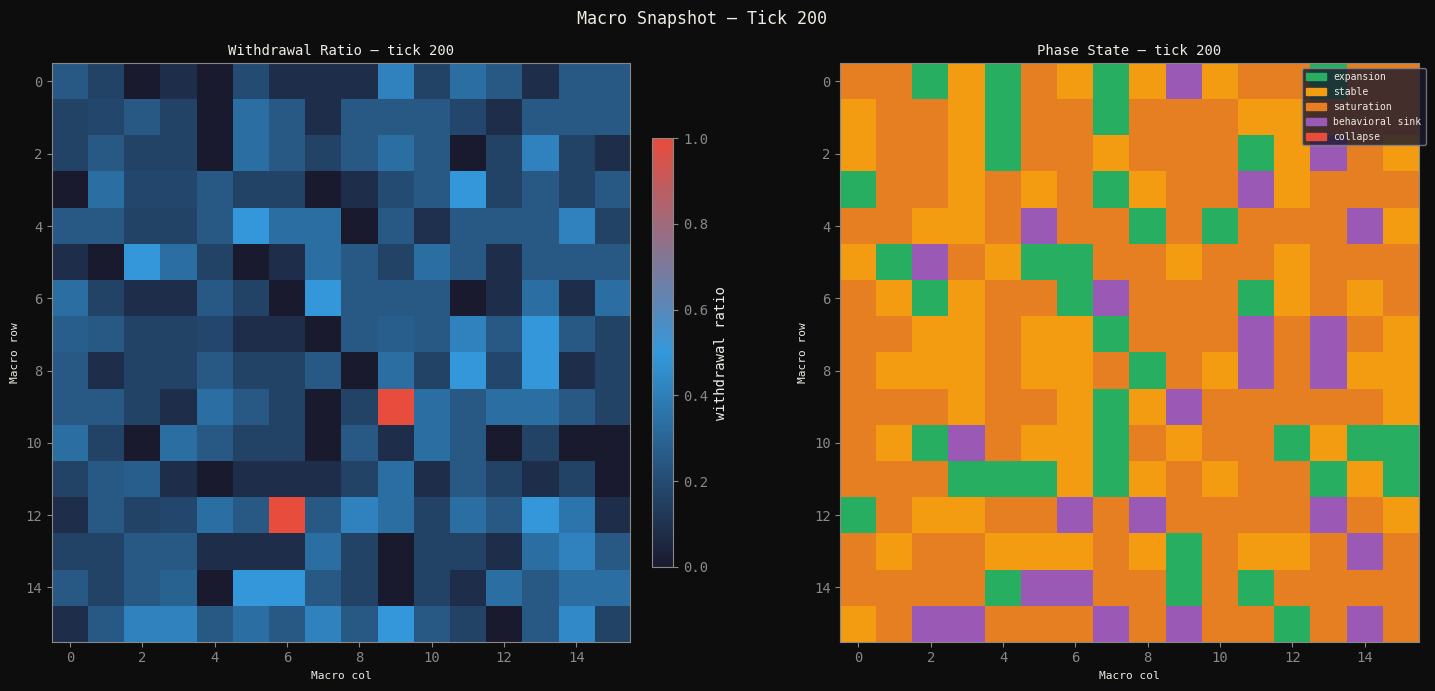

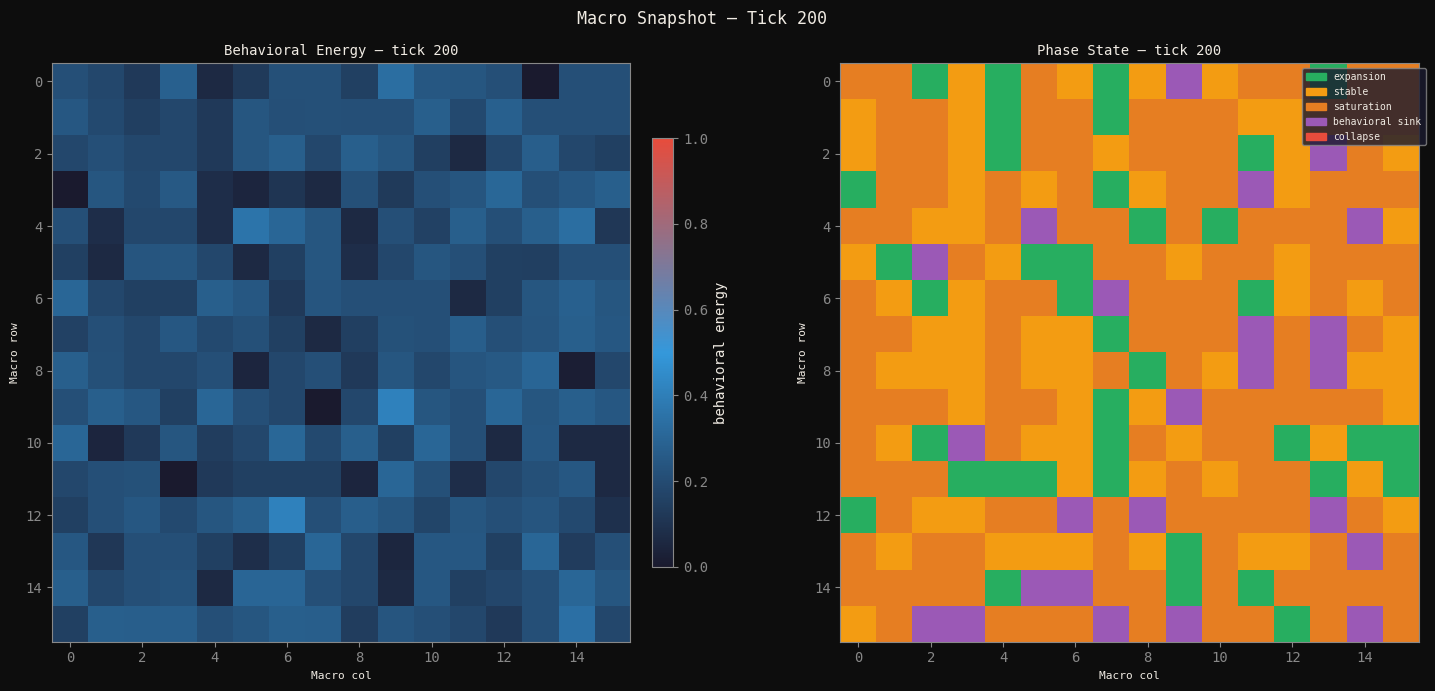

In [95]:
# ── Initial + mid + final snapshots ──────────────────────────────────────────
# We stored snapshots at ticks 0, MACRO_TICKS//2, and MACRO_TICKS in a fresh run.
# Here we just plot the final state (live grid after the run).

plot_macro_snapshot(macro_grid, metric='withdrawal_ratio')
plot_macro_snapshot(macro_grid, metric='behavioral_energy')


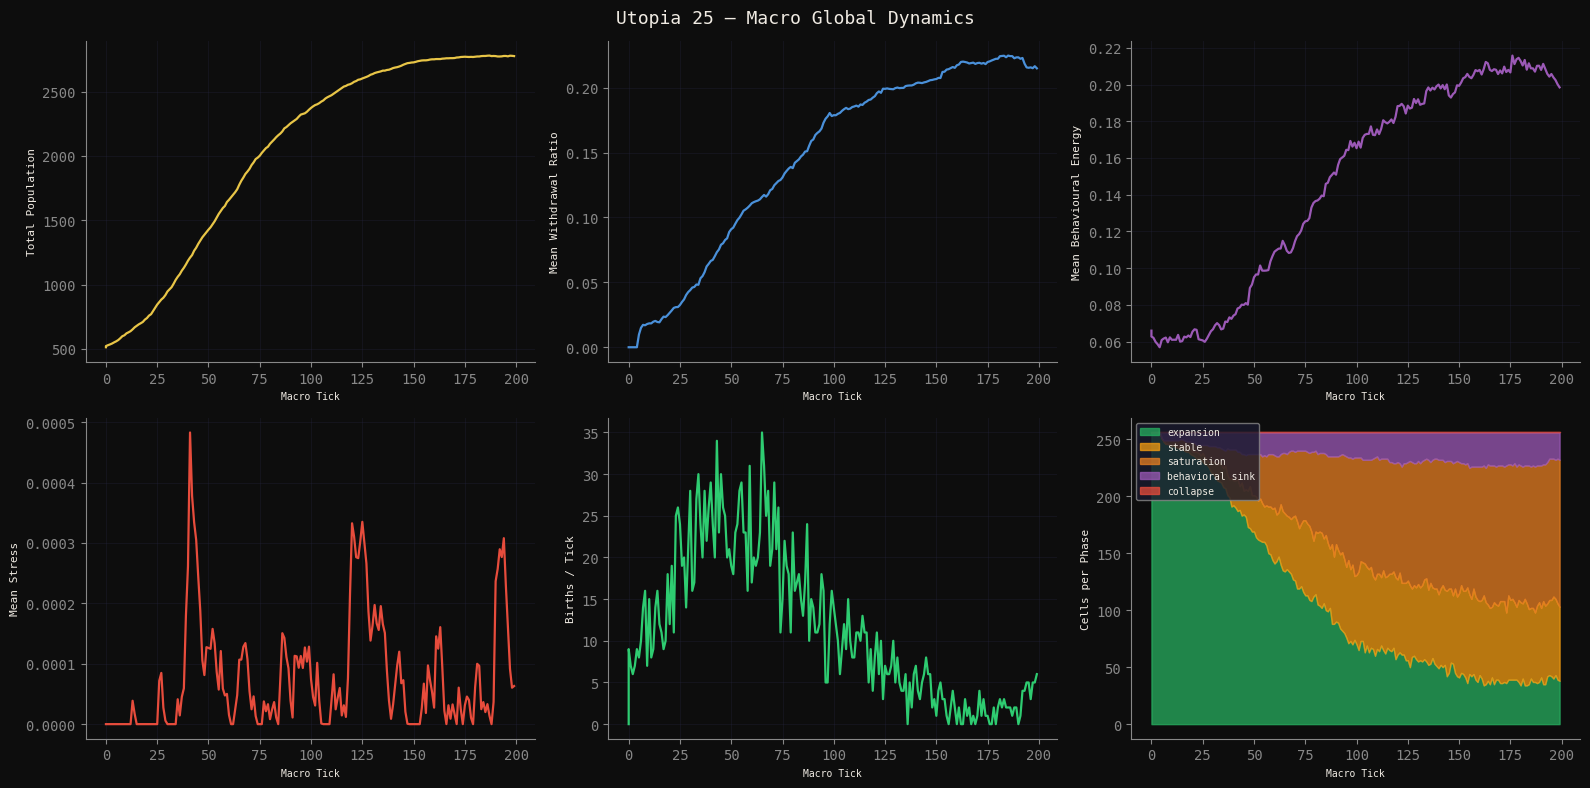

In [96]:
# ── Global time-series ───────────────────────────────────────────────────────
plot_macro_timeseries(macro_grid)


---
## Phase 14 — Analysis & Results

In [97]:
# ── Summary table ────────────────────────────────────────────────────────────
print("\n── Final macro cell summary ─────────────────────────────────────────────")
print(f"  {'Cell':<10} {'Pop':>5} {'Withdrawn':>10} {'W-ratio':>8} "
      f"{'B-Energy':>9} {'Phase':<18}")
print("  " + "─" * 65)

all_cells_summary = []
for (r, c), cell in sorted(macro_grid.cells.items()):
    s = cell.stats
    all_cells_summary.append({
        'cell':   f"({r},{c})",
        'pop':    s.population,
        'wd':     s.withdrawal_ratio,
        'energy': s.behavioral_energy,
        'phase':  s.phase_state,
        'extinct':s.is_extinct,
    })

summary_df = pd.DataFrame(all_cells_summary)
phase_summary = summary_df.groupby('phase').size().reset_index(name='count')
phase_summary['pct'] = (phase_summary['count'] / len(summary_df) * 100).round(1)
print(phase_summary.to_string(index=False))

print(f"\n  Total alive cells:   {(~summary_df['extinct']).sum()}")
print(f"  Total extinct cells: {summary_df['extinct'].sum()}")
print(f"  Total population:    {summary_df['pop'].sum()}")
print(f"  Mean withdrawal:     {summary_df['wd'].mean():.3f}")
print(f"  Mean b-energy:       {summary_df['energy'].mean():.3f}")



── Final macro cell summary ─────────────────────────────────────────────
  Cell         Pop  Withdrawn  W-ratio  B-Energy Phase             
  ─────────────────────────────────────────────────────────────────
          phase  count  pct
behavioral_sink     24  9.4
      expansion     38 14.8
     saturation    129 50.4
         stable     65 25.4

  Total alive cells:   256
  Total extinct cells: 0
  Total population:    2777
  Mean withdrawal:     0.215
  Mean b-energy:       0.198


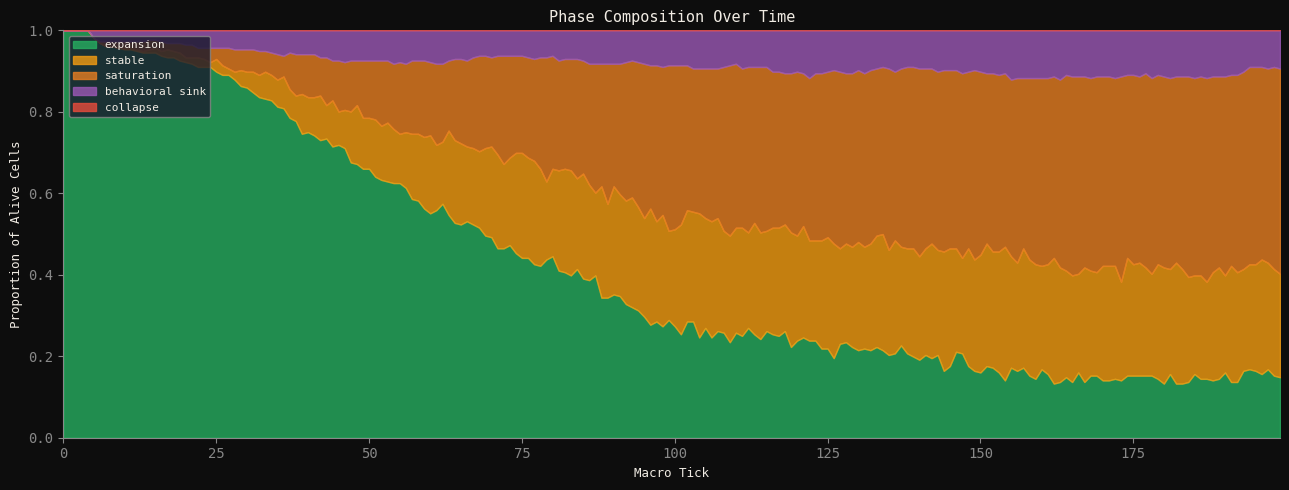

In [98]:
# ── Phase trajectory (stacked area, already in timeseries — here as proportions) ─
h   = macro_grid.history
df  = pd.DataFrame(h)
for ph in PHASE_ORDER:
    df[ph] = df['phase_counts'].apply(lambda d: d.get(ph, 0))

alive_cells_ts = df['alive_cells'].replace(0, np.nan)
fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(df))
for ph in PHASE_ORDER:
    prop = df[ph].values / alive_cells_ts.fillna(1).values
    ax.fill_between(df['tick'], bottom, bottom + prop,
                    alpha=0.8, label=ph.replace('_',' '),
                    color=PHASE_COLORS[ph])
    bottom += prop
ax.set_xlim(df['tick'].min(), df['tick'].max())
ax.set_ylim(0, 1)
ax.set_xlabel('Macro Tick', fontsize=9)
ax.set_ylabel('Proportion of Alive Cells', fontsize=9)
ax.set_title('Phase Composition Over Time', color=PALETTE['text'], fontsize=11)
ax.legend(loc='upper left', fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


Most withdrawn cell:   (9, 9) | wd=1.000 | phase=behavioral_sink
Least withdrawn cell:  (0, 2)  | wd=0.000 | phase=expansion

── Inspecting most withdrawn cell ──────────────────────────────────────


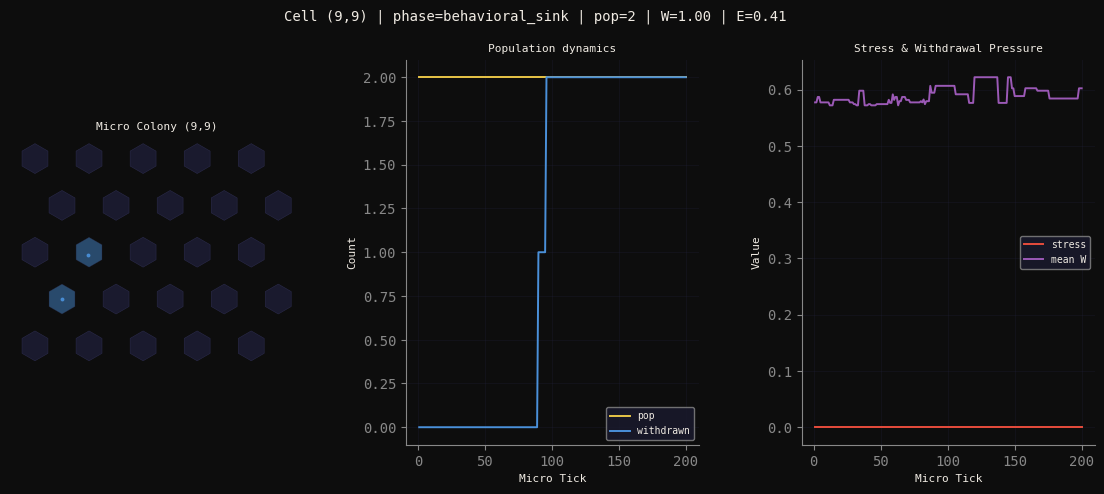


── Stats for cell (9,9) ──────────────────────────────
  population               2
  population_density       0.1667
  withdrawal_ratio         1.0000
  mean_stress              0.0000
  stress_variance          0.0000
  reproduction_rate        0.0000
  death_rate               0.0000
  occupancy_pressure       0.2500
  local_clustering         0.9200
  behavioral_momentum      0.0000
  behavioral_energy        0.4125
  phase_state              behavioral_sink
  births_last              0
  deaths_last              0
  is_extinct               False

── Inspecting least withdrawn (healthiest) cell ────────────────────────


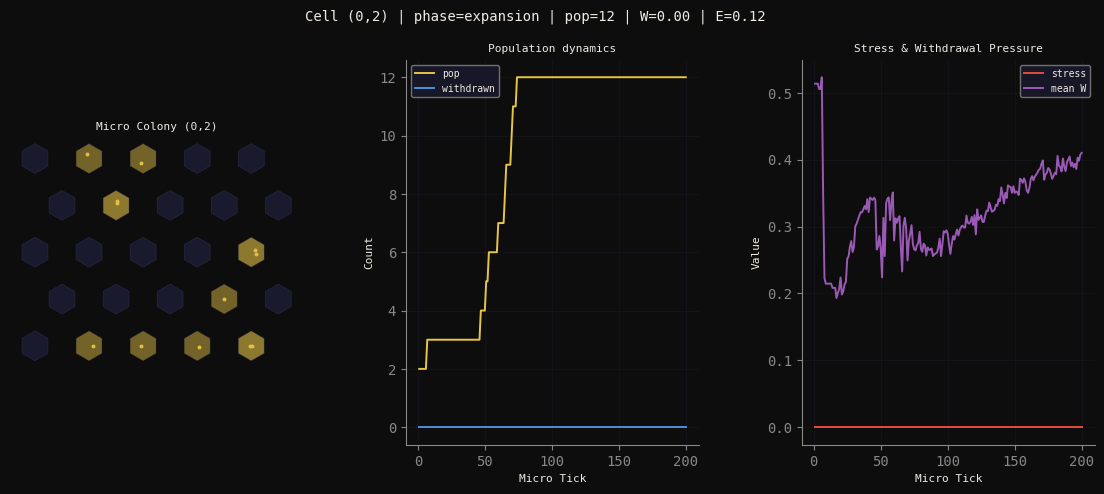


── Stats for cell (0,2) ──────────────────────────────
  population               12
  population_density       1.0000
  withdrawal_ratio         0.0000
  mean_stress              0.0000
  stress_variance          0.0000
  reproduction_rate        0.0000
  death_rate               0.0000
  occupancy_pressure       0.5000
  local_clustering         0.7000
  behavioral_momentum      0.0000
  behavioral_energy        0.1250
  phase_state              expansion
  births_last              0
  deaths_last              0
  is_extinct               False


In [99]:
# ── Micro inspection: most withdrawn surviving cell ──────────────────────────
alive = {pos: cell for pos, cell in macro_grid.cells.items()
         if not cell.stats.is_extinct and cell.stats.population > 0}

if alive:
    worst = max(alive, key=lambda pos: alive[pos].stats.withdrawal_ratio)
    best  = min(alive, key=lambda pos: alive[pos].stats.withdrawal_ratio)
    print(f"Most withdrawn cell:   {worst} | wd={alive[worst].stats.withdrawal_ratio:.3f} "
          f"| phase={alive[worst].stats.phase_state}")
    print(f"Least withdrawn cell:  {best}  | wd={alive[best].stats.withdrawal_ratio:.3f} "
          f"| phase={alive[best].stats.phase_state}")
    print("\n── Inspecting most withdrawn cell ──────────────────────────────────────")
    inspect_cell(macro_grid, *worst)
    print("\n── Inspecting least withdrawn (healthiest) cell ────────────────────────")
    inspect_cell(macro_grid, *best)
else:
    print("All colonies extinct.")


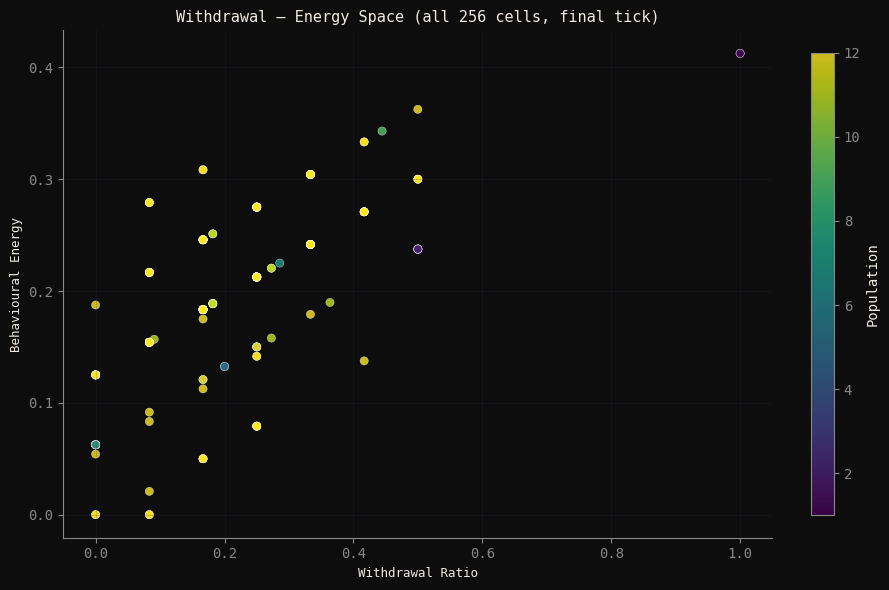

In [100]:
# ── Behavioural energy vs withdrawal scatter (all cells, final tick) ─────────
wd_vals  = [c.stats.withdrawal_ratio   for c in macro_grid.cells.values()]
be_vals  = [c.stats.behavioral_energy  for c in macro_grid.cells.values()]
pop_vals = [c.stats.population         for c in macro_grid.cells.values()]
phases   = [c.stats.phase_state        for c in macro_grid.cells.values()]
colors   = [PHASE_COLORS[p]            for p in phases]

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(wd_vals, be_vals, c=pop_vals, cmap='viridis',
                s=35, alpha=0.8, linewidths=0.3, edgecolors='white')
plt.colorbar(sc, ax=ax, label='Population', fraction=0.03)
ax.set_xlabel('Withdrawal Ratio', fontsize=9)
ax.set_ylabel('Behavioural Energy', fontsize=9)
ax.set_title(f'Withdrawal – Energy Space (all {MACRO_ROWS*MACRO_COLS} cells, final tick)',
             color=PALETTE['text'], fontsize=11)
ax.grid(True, alpha=0.2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


---
## Notes & Extensions

### What you should observe

| Run type | Expected pattern |
|---|---|
| Normal run (seed=42) | Expansion → uneven saturation → regional sinks; no global synchronised collapse |
| High-noise run | Faster regional fragmentation; more cells reaching `collapse` early |
| Low diffusion rates | Cells evolve more independently; less social contagion |
| Toroidal off | Edge cells develop differently (less neighbour influence) |

### Suggested extensions

1. **Migration**: allow a small fraction of agents from a saturated cell to relocate to adjacent macro cells each tick.
2. **Resource gradient**: assign per-cell carrying-capacity based on position (e.g. corners have lower `max_per_cell`).
3. **Dominance hierarchy**: add a `dominant_id` per macro cell that excludes lower-rank agents from reproduction.
4. **Recovery experiment**: at tick 100, remove the 25 % most-withdrawn cells' agents and observe if neighbours rebound.
5. **Sensitivity sweep**: vary `WITHDRAWAL_DIFFUSION_RATE` and record the tick of first `behavioral_sink` appearance.

### References

- Calhoun, J.B. (1973). *Death squared*. Proc. Royal Society of Medicine, 66(1), 80–88.
- Wolfram, S. (2002). *A New Kind of Science*. Wolfram Media.
- Epstein, J.M. & Axtell, R. (1996). *Growing Artificial Societies*. MIT Press.

---
*Hierarchical CA extension built on the Utopia 25 micro-layer simulation.*
